# Example for [passagemath-cmr](https://pypi.org/project/passagemath-cmr/)

## Sage code running *serverless in the browser* using WebAssembly

This notebook illustrates Seymour's decomposition of totally unimodular matrices and regular matroids provided by [passagemath-cmr](https://pypi.org/project/passagemath-cmr/) – one of the modularized pip-installable packages of the Sage library provided by the [passagemath project](https://github.com/passagemath).

In [4]:
import passagemath_polyhedra, passagemath_flint, passagemath_graphs, passagemath_nauty, passagemath_repl
from passagemath_cmr import matrix, unicode_art
from passagemath_graphs import matroids, Matroid, Graph, DiGraph, QQ, ZZ, graphs, digraphs
import sage.typeset.character_art
sage.typeset.character_art.MAX_WIDTH = 200

## 3.1 Matrices

The pip-installable package `passagemath-cmr` extends standard matrix types with specialized methods for Seymour's decomposition and recognition of totally unimodular (TU) matrices.

In [5]:
A = matrix([[1, 0], [-1, -1], [0, 1]], column_keys=['a', 'b'], row_keys=range(3)); A

Generic morphism:
  From: Free module generated by {'a', 'b'} over Integer Ring
  To:   Free module generated by {0, 1, 2} over Integer Ring

In [6]:
A._unicode_art_matrix()

   a  b 
0⎛ 1  0⎞
1⎜-1 -1⎟
2⎝ 0  1⎠

In [7]:
result, certificate = A.is_totally_unimodular(certificate=True); result, certificate

(True, GraphicNode (3×2))

In [8]:
certificate.graph()

Digraph on 4 vertices

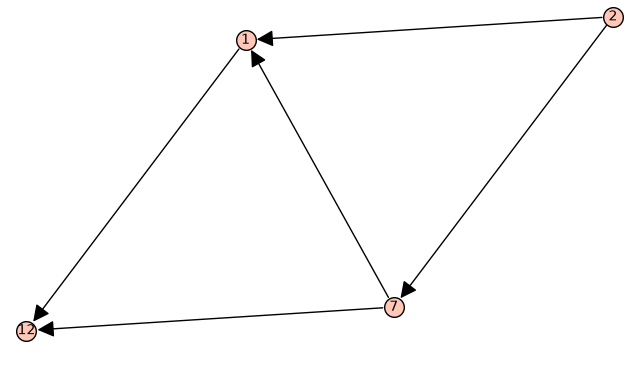

In [9]:
certificate.graph().plot()

All of these methods are made available by delegating to a specialized matrix element class `Matrix_cmr_chr_sparse`, in which matrices are backed by the CMR library.

## 3.2 Module morphisms

The package `passagemath-modules` provides linear algebra facilities in a style favored in algebraic combinatorics. Users can define vector spaces and free modules with distinguished bases whose elements are indexed by arbitrary objects. Linear maps (module morphisms) between such vector spaces or modules are represented by matrices whose rows and columns are indexed by the basis indices.

In [10]:
A2 = matrix([[-1,  0,  0,  0,  1, -1,  0],
             [ 1,  0,  0,  1, -1,  1,  0],
             [ 0, -1,  0, -1,  1, -1,  0],
             [ 0,  1,  0,  0,  0,  0,  1],
             [ 0,  0,  1, -1,  1,  0,  1],
             [ 0,  0, -1,  1, -1,  0,  0]],
            column_keys=['a', 'b', 'c', 'd', 'e', 'f', 'g'],
            row_keys=range(6))

In [11]:
A2._unicode_art_matrix()

   a  b  c  d  e  f  g 
0⎛-1  0  0  0  1 -1  0⎞
1⎜ 1  0  0  1 -1  1  0⎟
2⎜ 0 -1  0 -1  1 -1  0⎟
3⎜ 0  1  0  0  0  0  1⎟
4⎜ 0  0  1 -1  1  0  1⎟
5⎝ 0  0 -1  1 -1  0  0⎠

In [12]:
A2_result, A2_certificate = A2.is_totally_unimodular(certificate=True); A2_result, A2_certificate

(True, GraphicNode (6×7))

In [13]:
A2_certificate.graph().incidence_matrix(vertices=True,edges=True)._unicode_art_matrix()

  (0, 6) (0, 8) (3, 4) (3, 8) (3, 9) (4, 0) (4, 6) (4, 9) (5, 3) (5, 4) (5, 6) (9, 0) (9, 8) 
0⎛    -1     -1      0      0      0      1      0      0      0      0      0      1      0⎞
3⎜     0      0     -1     -1     -1      0      0      0      1      0      0      0      0⎟
4⎜     0      0      1      0      0     -1     -1     -1      0      1      0      0      0⎟
5⎜     0      0      0      0      0      0      0      0     -1     -1     -1      0      0⎟
6⎜     1      0      0      0      0      0      1      0      0      0      1      0      0⎟
8⎜     0      1      0      1      0      0      0      0      0      0      0      0      1⎟
9⎝     0      0      0      0      1      0      0      1      0      0      0     -1     -1⎠

## 3.3 Graphs

Graph structures have a direct link to total unimodularity. The vertex-edge incidence matrix of any directed graph is totally unimodular.

In [14]:
G_directed = DiGraph([(0, 1), (1, 2), (2, 0)])
m_directed = G_directed.incidence_matrix(oriented=True)
res_directed, cert_directed = m_directed.is_totally_unimodular(certificate=True)

In [15]:
res_directed, cert_directed

(True, GraphicNode (3×3))

For undirected graphs, the incidence matrix is totally unimodular if and only if the graph is bipartite.

In [16]:
c4 = Graph([(0, 1), (1, 2), (2, 3), (3, 0)])
c5 = Graph([(0, 1), (1, 2), (2, 3), (3, 4), (4, 0)])
res_c4 = c4.incidence_matrix().is_totally_unimodular()
res_c5, cert_c5 = c5.incidence_matrix().is_totally_unimodular(certificate=True)

In [17]:
print("C4 is TU:", res_c4)
print("C5 is TU:", res_c5)
print("C5 certificate violating root node:", cert_c5[0])

C4 is TU: True
C5 is TU: False
C5 certificate violating root node: ThreeConnectedIrregularNode (5×5)


### 3.3.1 Odd Cycle Packing Number

We can check whether a connected undirected graph has odd cycle packing number $\mathrm{ocp}(G) \le 1$. It is done by first checking if the incidence matrix is totally unimodular. If so, it is a bipartite graph with no odd cycle ($\mathrm{ocp}(G) = 0$). If not, we can find a basis $B$, which contains at least one odd cycle (otherwise it cannot be a basis). Then by left multiplying the inverse of the basis and checking if the obtained matrix is totally unimodular, we can claim that the graph has odd cycle packing number $\log_2(|\det(B)|)$ (which is 1) if the obtained matrix is totally unimodular.

In the following implementation, we use the `rref` function to compute the new matrix after left multiplying the inverse of the basis for efficiency.

In [18]:
gt = graphs.GrotzschGraph()
At = gt.incidence_matrix(vertices=True, edges=True).matrix()
res_gt_tu, cert_gt_tu = At.is_totally_unimodular(certificate=True)
res_gt_rref_tu, cert_gt_rref_tu = At.rref().is_totally_unimodular(certificate=True)

In [19]:
print("Grötzsch Graph incidence matrix is TU:", res_gt_tu)
print("Grötzsch Graph certificate:", cert_gt_tu)
print("Grötzsch Graph rref matrix is TU:", res_gt_rref_tu)
print("Grötzsch Graph rref certificate:", cert_gt_rref_tu)

Grötzsch Graph incidence matrix is TU: False
Grötzsch Graph certificate: (ThreeConnectedIrregularNode (11×20), ((10, 9, 8, 7, 6), (19, 18, 17, 16, 15)))
Grötzsch Graph rref matrix is TU: True
Grötzsch Graph rref certificate: CographicNode (11×20)


In [29]:
A_K6 = graphs.CompleteGraph(6).incidence_matrix()
res_K6_tu, cert_K6_tu = A_K6.is_totally_unimodular(certificate=True)
from sage.rings.real_double import RDF
res_K6_rref_tu, cert_K6_rref_tu = A_K6.change_ring(RDF).rref().change_ring(ZZ).is_totally_unimodular(certificate=True)

In [30]:
print("K6 incidence matrix is TU:", res_K6_tu)
print("K6 certificate:", cert_K6_tu)
print("K6 rref matrix is TU:", res_K6_rref_tu)
print("K6 rref certificate:", cert_K6_rref_tu)

K6 incidence matrix is TU: False
K6 certificate: (ThreeConnectedIrregularNode (6×15), ((5, 4, 3), (14, 13, 12)))
K6 rref matrix is TU: False
K6 rref certificate: (SeriesParallelReductionNode (6×15), ((4, 3, 2), (14, 13, 12)))


### 3.3.2 Recognition algorithm of network matrices

The `passagemath-cmr` package also provides the recognition algorithm of network matrices. It can return the directed graph certificate of a network matrix, which can be used to reconstruct the original matrix.

In [31]:
A2_g = matrix([[-1,  0,  0,  0,  1, -1,  0],
             [ 1,  0,  0,  1, -1,  1,  0],
             [ 0, -1,  0, -1,  1, -1,  0],
             [ 0,  1,  0,  0,  0,  0,  1],
             [ 0,  0,  1, -1,  1,  0,  1],
             [ 0,  0, -1,  1, -1,  0,  0]],
            column_keys=['a', 'b', 'c', 'd', 'e', 'f', 'g'],
            row_keys=range(6))

In [32]:
A2_g_result, A2_g_certificate = A2_g.is_totally_unimodular(certificate=True); A2_g_result, A2_g_certificate

(True, GraphicNode (6×7))

In [33]:
G_g = A2_g_certificate.graph()

In [34]:
M_g = G_g.incidence_matrix(vertices=True, edges=True)

In [35]:
M_g._unicode_art_matrix()

  (0, 6) (0, 8) (3, 4) (3, 8) (3, 9) (4, 0) (4, 6) (4, 9) (5, 3) (5, 4) (5, 6) (9, 0) (9, 8) 
0⎛    -1     -1      0      0      0      1      0      0      0      0      0      1      0⎞
3⎜     0      0     -1     -1     -1      0      0      0      1      0      0      0      0⎟
4⎜     0      0      1      0      0     -1     -1     -1      0      1      0      0      0⎟
5⎜     0      0      0      0      0      0      0      0     -1     -1     -1      0      0⎟
6⎜     1      0      0      0      0      0      1      0      0      0      1      0      0⎟
8⎜     0      1      0      1      0      0      0      0      0      0      0      0      1⎟
9⎝     0      0      0      0      1      0      0      1      0      0      0     -1     -1⎠

In [36]:
row_keys_g, forest_order_g = zip(*A2_g_certificate.forest_edges().items())
column_keys_g, coforest_order_g = zip(*A2_g_certificate.coforest_edges().items())
row_order_g = G_g.vertices()[:-1]
AA_g = M_g.matrix(row_order=row_order_g, column_order=forest_order_g).inverse() * M_g.matrix(row_order=row_order_g, column_order=coforest_order_g)
print(AA_g)

[-1  0  0  0  1 -1  0]
[ 1  0  0  1 -1  1  0]
[ 0 -1  0 -1  1 -1  0]
[ 0  1  0  0  0  0  1]
[ 0  0  1 -1  1  0  1]
[ 0  0 -1  1 -1  0  0]


In [37]:
matrix(AA_g, base_ring=ZZ, row_keys=row_keys_g, column_keys=column_keys_g) == A2_g

True

Here are some more examples of the two excluded minors $K_5$, $K_{3,3}$ for conetwork/network matrices.

In [38]:
K5 = digraphs.Complete(5)
M_K5 = K5.incidence_matrix()

In [39]:
M_K5.is_conetwork_matrix()

False

In [40]:
M_K5.is_network_matrix()

True

In [41]:
K33_undirect = graphs.CompleteBipartiteGraph(3, 3)
K33 = K33_undirect.orient(lambda e: e if e[0] < e[1] else (e[1], e[0], e[2]))
M_K33 = K33.incidence_matrix(vertices=True, edges=True)

In [42]:
M_K33.is_conetwork_matrix()

False

In [43]:
M_K33.is_network_matrix()

True

In [44]:
res_K33, cert_K33 = M_K33.is_totally_unimodular(certificate=True)

In [45]:
cert_K33

GraphicNode (6×9)

## 3.4 Matroids

The packages `passagemath-graphs` and `passagemath-modules` provide facilities for matroid theory. A comprehensive catalog of known matroids is a good starting point for investigations. We can inspect the regular matroid $R_{10}$ and perform Seymour's decomposition.

In [46]:
R10 = matroids.catalog.R10()

In [47]:
sorted(R10.groundset())

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']

In [48]:
R10_rr = R10.representation(reduced=True, order=True)
# Reference A from cell 4
R10_rr, A

(Generic morphism:
   From: Free module generated by {'f', 'g', 'h', 'i', 'j'} over Integer Ring
   To:   Free module generated by {'a', 'b', 'c', 'd', 'e'} over Integer Ring,
 Generic morphism:
   From: Free module generated by {'a', 'b'} over Integer Ring
   To:   Free module generated by {0, 1, 2} over Integer Ring)

In [49]:
R10_rr._unicode_art_matrix()

   f  g  h  i  j 
a⎛-1  1  0  0  1⎞
b⎜ 1 -1  1  0  0⎟
c⎜ 0  1 -1  1  0⎟
d⎜ 0  0  1 -1  1⎟
e⎝ 1  0  0  1 -1⎠

In [50]:
R10_tu, R10_certificate = R10_rr.is_totally_unimodular(certificate=True); R10_certificate

R10Node (5×5) a reduced matrix representation of R10 matroid

In [51]:
R10_certificate.morphism()

Generic morphism:
  From: Free module generated by {'f', 'g', 'h', 'i', 'j'} over Integer Ring
  To:   Free module generated by {'a', 'b', 'c', 'd', 'e'} over Integer Ring

In [52]:
R10_certificate.morphism()._unicode_art_matrix()

   f  g  h  i  j 
a⎛-1  1  0  0  1⎞
b⎜ 1 -1  1  0  0⎟
c⎜ 0  1 -1  1  0⎟
d⎜ 0  0  1 -1  1⎟
e⎝ 1  0  0  1 -1⎠

In [53]:
R10D = R10.dual(); R10D

Regular matroid of rank 5 on 10 elements with 162 bases

In [54]:
R10D_rr = R10D.representation(reduced=True, order=True); R10D_rr

Generic morphism:
  From: Free module generated by {'a', 'b', 'c', 'd', 'e'} over Integer Ring
  To:   Free module generated by {'f', 'g', 'h', 'i', 'j'} over Integer Ring

In [55]:
R10D_rr._unicode_art_matrix()

   a  b  c  d  e 
f⎛ 1 -1  0  0 -1⎞
g⎜-1  1 -1  0  0⎟
h⎜ 0 -1  1 -1  0⎟
i⎜ 0  0 -1  1 -1⎟
j⎝-1  0  0 -1  1⎠

In [112]:
R10D.is_isomorphic(R10)  # Does not work on JupyterLite yet

<class 'ModuleNotFoundError'>: No module named 'sage.matrix.matrix_integer_pari'

In [57]:
R10D_tu, R10D_certificate = R10D_rr.is_totally_unimodular(certificate=True); R10D_certificate

R10Node (5×5) a reduced matrix representation of R10 matroid

In [58]:
R10_1_R10 = R10.direct_sum(R10)
R10_1_R10_reg = Matroid(R10_1_R10, regular=True)
R10_1_R10_reg.representation()

[1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1]
[0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1]
[0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0]
[0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0]
[0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0 1 0 1]
[0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0]
[0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0]
[0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 0 0 0]
[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0 1 0]
[0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 0]

In [59]:
R10_1_R10_rr = R10_1_R10_reg.representation(reduced=True, order=True); R10_1_R10_rr

Generic morphism:
  From: Free module generated by {(0, 'i'), (0, 'd'), (0, 'c'), (1, 'e'), (1, 'i'), (1, 'f'), (1, 'a'), (0, 'j'), (1, 'h'), (0, 'e')} over Integer Ring
  To:   Free module generated by {(0, 'f'), (0, 'b'), (1, 'g'), (1, 'd'), (0, 'a'), (1, 'c'), (0, 'h'), (1, 'j'), (1, 'b'), (0, 'g')} over Integer Ring

In [60]:
R10_1_R10_tu, R10_1_R10_certificate = R10_1_R10_rr.is_totally_unimodular(certificate=True); R10_1_R10_certificate

OneSumNode (10×10) with 2 children

In [61]:
unicode_art(R10_1_R10_certificate.as_ordered_tree())

╭─────────────OneSumNode (10×10) with 2 children─────────────╮
│                                                            │
R10Node (5×5) a reduced matrix representation of R10 matroid R10Node (5×5) a reduced matrix representation of R10 matroid

In [62]:
R10_1_R10_rr._unicode_art_matrix()

         (0, 'c') (0, 'd') (0, 'e') (0, 'i') (0, 'j') (1, 'a') (1, 'e') (1, 'f') (1, 'h') (1, 'i') 
(0, 'a')⎛       1        1        1        1        1        0        0        0        0        0⎞
(0, 'b')⎜       1        0        1        0        1        0        0        0        0        0⎟
(0, 'f')⎜       0        0        1        1        1        0        0        0        0        0⎟
(0, 'g')⎜       1        1        0        0        1        0        0        0        0        0⎟
(0, 'h')⎜       0        1        0        1        1        0        0        0        0        0⎟
(1, 'b')⎜       0        0        0        0        0        1        1        1        1        1⎟
(1, 'c')⎜       0        0        0        0        0        1        1        0        1        0⎟
(1, 'd')⎜       0        0        0        0        0        0        1        1        1        0⎟
(1, 'g')⎜       0        0        0        0        0        1        1        0        0        1⎟


In [63]:
R10_1_R10_certificate.block_matrix_form()

[1 1 1 1 1|0 0 0 0 0]
[1 0 1 0 1|0 0 0 0 0]
[0 0 1 1 1|0 0 0 0 0]
[1 1 0 0 1|0 0 0 0 0]
[0 1 0 1 1|0 0 0 0 0]
[---------+---------]
[0 0 0 0 0|1 1 1 1 1]
[0 0 0 0 0|1 1 0 0 1]
[0 0 0 0 0|0 1 1 0 1]
[0 0 0 0 0|1 1 0 1 0]
[0 0 0 0 0|0 1 1 1 0]

### 3.4.1 Non-Regular Matroids (AG23minus)

Not all matroids are regular. The `AG23minus` matroid is representable over GF(3) (ternary) but is not binary, meaning it cannot be represented by a totally unimodular matrix.

In [64]:
AG23minus = matroids.catalog.AG23minus()

In [65]:
AG23minus.is_regular()

False

In [66]:
AG23minus.is_binary(), AG23minus.is_ternary()

(False, True)

In [67]:
AG23minus_ternary = AG23minus.ternary_matroid()

In [68]:
AG23minus_rr = AG23minus_ternary.representation(reduced=True, order=True)

In [69]:
AG23minus_rr._unicode_art_matrix()

  c d e f g 
a⎛1 0 2 1 2⎞
b⎜1 1 2 2 1⎟
h⎝0 1 1 2 2⎠

In [70]:
AG23minus_tu, AG23minus_certificate = AG23minus_rr.is_totally_unimodular(certificate=True); AG23minus_certificate

(None, (('a',), ('e',)))

## 3.5 Polyhedra and linear programming

The Sage library provides a simple modeling facility for mixed-integer linear programs with access to various numerical solvers as backends, as well as facilities for convex polyhedra. In the passagemath system, this functionality is available in the pip-installable package **passagemath-polyhedra**.

In [71]:
from sage.numerical.mip import MixedIntegerLinearProgram

### 3.5.1 Network flow

As an illustrating example, we set up a min-cost flow problem.

In [72]:
GP = graphs.PetersenGraph(); GP

Petersen graph: Graph on 10 vertices

In [73]:
DP = next(GP.acyclic_orientations()); DP

Petersen graph: Digraph on 10 vertices

In [74]:
DPA = DP.incidence_matrix(vertices=True, edges=True); DPA

Generic morphism:
  From: Free module generated by {(0, 5), (0, 4), (9, 6), (9, 4), (9, 7), (7, 5), (7, 2), (8, 6), (8, 5), (8, 3), (3, 4), (3, 2), (1, 0), (1, 6), (1, 2)} over Integer Ring
  To:   Free module generated by {0, 6, 5, 4, 2, 9, 7, 8, 3, 1} over Integer Ring

In [75]:
DPA._unicode_art_matrix()

  (0, 4) (0, 5) (1, 0) (1, 2) (1, 6) (3, 2) (3, 4) (7, 2) (7, 5) (8, 3) (8, 5) (8, 6) (9, 4) (9, 6) (9, 7) 
0⎛    -1     -1      1      0      0      0      0      0      0      0      0      0      0      0      0⎞
1⎜     0      0     -1     -1     -1      0      0      0      0      0      0      0      0      0      0⎟
2⎜     0      0      0      1      0      1      0      1      0      0      0      0      0      0      0⎟
3⎜     0      0      0      0      0     -1     -1      0      0      1      0      0      0      0      0⎟
4⎜     1      0      0      0      0      0      1      0      0      0      0      0      1      0      0⎟
5⎜     0      1      0      0      0      0      0      0      1      0      1      0      0      0      0⎟
6⎜     0      0      0      0      1      0      0      0      0      0      0      1      0      1      0⎟
7⎜     0      0      0      0      0      0      0     -1     -1      0      0      0      0      0      1⎟
8⎜     0      0      0      

To set up a feasible min-cost flow problem, we pick a flow imbalance from the range of the matrix (image of this linear map).

In [76]:
DPA.image()

Free module generated by {0, 1, 2, 3, 4, 5, 6, 7, 8} over Integer Ring

In [77]:
import random
dom = DPA.domain()
random_flow = dom.sum(random.randint(0, 5) * dom.monomial(e) for e in dom.basis().keys())
imbalance = DPA(random_flow); imbalance

-2*B[1] + 2*B[2] - B[3] + 6*B[4] + 5*B[5] + 8*B[6] + 2*B[7] - 9*B[8] - 11*B[9]

In [78]:
from sage.modules.free_module_element import vector
imbalance_vector = vector(QQ, [imbalance[v] for v in sorted(imbalance.parent().basis().keys())])
Mincostflow = MixedIntegerLinearProgram(solver='GLPK', base_ring=QQ)
flow = Mincostflow.new_variable(real=True, nonnegative=True, name="x"); flow
Mincostflow.add_constraint(DPA.matrix() * flow, min=imbalance_vector, max=imbalance_vector)

In [79]:
Mincostflow.show()

Constraints:
  0.0 <= - x[0] - x[1] + x[2] <= 0.0
  -2.0 <= - x[2] - x[3] - x[4] <= -2.0
  2.0 <= x[3] + x[5] + x[7] <= 2.0
  -1.0 <= - x[5] - x[6] + x[9] <= -1.0
  6.0 <= x[0] + x[6] + x[12] <= 6.0
  5.0 <= x[1] + x[8] + x[10] <= 5.0
  8.0 <= x[4] + x[11] + x[13] <= 8.0
  2.0 <= - x[7] - x[8] + x[14] <= 2.0
  -9.0 <= - x[9] - x[10] - x[11] <= -9.0
  -11.0 <= - x[12] - x[13] - x[14] <= -11.0
Variables:
  x[0] = x_0 is a continuous variable (min=0.0, max=+oo)
  x[1] = x_1 is a continuous variable (min=0.0, max=+oo)
  x[2] = x_2 is a continuous variable (min=0.0, max=+oo)
  x[3] = x_3 is a continuous variable (min=0.0, max=+oo)
  x[4] = x_4 is a continuous variable (min=0.0, max=+oo)
  x[5] = x_5 is a continuous variable (min=0.0, max=+oo)
  x[6] = x_6 is a continuous variable (min=0.0, max=+oo)
  x[7] = x_7 is a continuous variable (min=0.0, max=+oo)
  x[8] = x_8 is a continuous variable (min=0.0, max=+oo)
  x[9] = x_9 is a continuous variable (min=0.0, max=+oo)
  x[10] = x_10 is a cont

In [80]:
DPP = Mincostflow.polyhedron(base_ring=QQ)
print(DPP)

A 6-dimensional polyhedron in QQ^15 defined as the convex hull of 56 vertices


In [81]:
DPP.vertices_matrix()

15 x 56 dense matrix over Rational Field

In [82]:
DPP.rays_list()

[]

### 3.5.2 Stable sets

For perfect graphs, the fractional stable set polyhedron (QSTAB) is equal to the stable set polyhedron (STAB), which is integral. Although QSTAB is integral for perfect graphs, the constraint matrix (clique-vertex incidence matrix) is not necessarily totally unimodular. When the matrix is non-TU, we can use the decomposition certificate to investigate the failure.

In [83]:
def clique_vertex_incidence_matrix(G):
    cliques = [tuple(sorted(Q)) for Q in G.cliques_maximal()]
    vertices = list(G.vertices(sort=True))
    data = [[1 if v in clique else 0 for v in vertices] for clique in cliques]
    return matrix(data, column_keys=vertices, row_keys=cliques)

W6 = graphs.WheelGraph(6)
W6_clique_vertex_incidence_matrix = clique_vertex_incidence_matrix(W6)

W6_stab_mip = MixedIntegerLinearProgram(solver='GLPK', base_ring=QQ)
x = W6_stab_mip.new_variable(real=True, nonnegative=True, name="x")
for v in W6.vertices():
    W6_stab_mip.set_max(x[v], 1)
for clique in W6.cliques_maximal():
    W6_stab_mip.add_constraint(sum(x[v] for v in clique) <= 1)

In [84]:
W6_clique_vertex_incidence_matrix._unicode_art_matrix()

          0 1 2 3 4 5 
(0, 1, 2)⎛1 1 1 0 0 0⎞
(0, 1, 5)⎜1 1 0 0 0 1⎟
(0, 2, 3)⎜1 0 1 1 0 0⎟
(0, 3, 4)⎜1 0 0 1 1 0⎟
(0, 4, 5)⎝1 0 0 0 1 1⎠

In [85]:
W6_qstab = W6_stab_mip.polyhedron(base_ring=QQ)
print(W6_qstab)

A 6-dimensional polyhedron in QQ^6 defined as the convex hull of 13 vertices


In [86]:
W6_qstab.vertices_matrix()

[  0   0   0   0   0   0   1   1 1/2   1   0   0   0]
[  0   0   0   1   1   1   0   0 1/2   0   0   0   0]
[  0   0   1   0   0   0   0   0 1/2   1   1   0   0]
[  0   0   0   0   0   1   1   0 1/2   0   0   1   0]
[  1   0   1   0   1   0   0   0 1/2   0   0   0   0]
[  0   1   0   0   0   0   0   0   0   0   0   0   0]

The stable set polyhedron of $W_6$ contains fractional vertices (non-integral), because $W_6$ contains a $C_5$ cycle and is thus not perfect.

In [87]:
W6_clique_vertex_incidence_matrix.is_totally_unimodular()

False

#### Interactive Wheel Graph Explorer

Let's check the total unimodularity of clique-vertex incidence matrices for the family of Wheel graphs $W_n$.

You can adjust the size of the Wheel Graph $W_n$ and inspect the total unimodularity of its clique-vertex incidence matrix.

In [89]:
n = 8

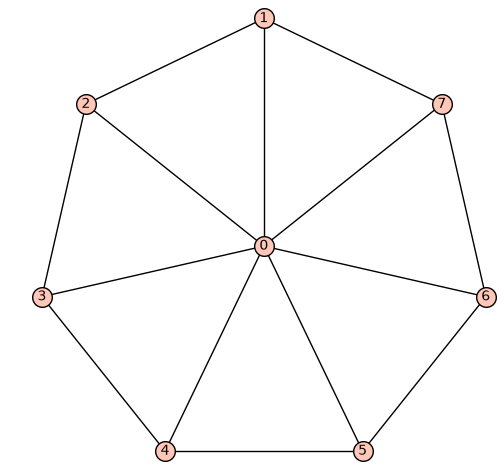

In [90]:
W_interactive = graphs.WheelGraph(n)
W_interactive_tu, W_interactive_cert = clique_vertex_incidence_matrix(W_interactive).is_totally_unimodular(certificate=True)
W_interactive.plot()

In [92]:
print(f"W_{n} is totally unimodular: {W_interactive_tu}")
if not W_interactive_tu:
    print("Violation certificate root node:", W_interactive_cert[0])

W_8 is totally unimodular: False
Violation certificate root node: ThreeConnectedIrregularNode (7×8)


#### Search for small non-unimodular examples
We can search for small non-unimodular graphs on 5 and 6 vertices.

This section does not work on JupyterLite yet.

In [94]:
not_unimodular_on_5 = [G for G in graphs(5) 
                       if not clique_vertex_incidence_matrix(G).is_totally_unimodular()]
not_unimodular_on_5

<class 'sage.features.FeatureNotPresentError'>: nauty_geng is not available.
Executable 'geng' not found on PATH.

In [95]:
not_unimodular_on_5[0].is_cycle()

<class 'NameError'>: name 'not_unimodular_on_5' is not defined

In [96]:
not_unimodular_on_6 = [G for G in graphs(6) 
                       if G.is_connected() 
                       and not clique_vertex_incidence_matrix(G).is_totally_unimodular()]
not_unimodular_on_6

<class 'sage.features.FeatureNotPresentError'>: nauty_geng is not available.
Executable 'geng' not found on PATH.

In [97]:
not_unimodular_on_6[0].is_perfect()

<class 'NameError'>: name 'not_unimodular_on_6' is not defined

In [98]:
perfect_but_not_unimodular_on_6 = [G for G in graphs(6) 
                                   if G.is_connected() and G.is_perfect() 
                                   and not clique_vertex_incidence_matrix(G).is_totally_unimodular()]
perfect_but_not_unimodular_on_6

<class 'sage.features.FeatureNotPresentError'>: nauty_geng is not available.
Executable 'geng' not found on PATH.

In [99]:
for g in perfect_but_not_unimodular_on_6: 
    print(clique_vertex_incidence_matrix(g)._unicode_art_matrix())

<class 'NameError'>: name 'perfect_but_not_unimodular_on_6' is not defined

In [100]:
[
    unicode_art(
        clique_vertex_incidence_matrix(G)
        .is_totally_unimodular(certificate=True)[1][0]
        .as_ordered_tree()
    )
    for G in perfect_but_not_unimodular_on_6
]

<class 'NameError'>: name 'perfect_but_not_unimodular_on_6' is not defined

In [101]:
len(list(graphs(9)))  # OEIS A000088

<class 'sage.features.FeatureNotPresentError'>: nauty_geng is not available.
Executable 'geng' not found on PATH.

In [102]:
perfect_but_not_unimodular_on_7 = [G for G in graphs(7) 
                                   if G.is_connected() and G.is_perfect() 
                                   and not clique_vertex_incidence_matrix(G).is_totally_unimodular()]
perfect_but_not_unimodular_on_7

<class 'sage.features.FeatureNotPresentError'>: nauty_geng is not available.
Executable 'geng' not found on PATH.

In [113]:
from sage.matrix.seymour_decomposition import SeriesParallelReductionNode

In [114]:
def interesting_stuff():
    for G in perfect_but_not_unimodular_on_7:
        result, certificate = clique_vertex_incidence_matrix(G).is_totally_unimodular(certificate=True, stop_when_nonTU=False)
        if not isinstance(certificate[0], SeriesParallelReductionNode):
            yield G, certificate[0].as_ordered_tree() 
for G345678, tree in interesting_stuff():
    print(clique_vertex_incidence_matrix(G345678)._unicode_art_matrix())
    print(tree)

<class 'NameError'>: name 'perfect_but_not_unimodular_on_7' is not defined

## 3.6 Detailed example for Seymour's decomposition

We can analyze a larger matrix `MM` of size 16x16 to get one possible Seymour decomposition tree.

In [115]:
MM = matrix([[ 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
             [ 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
             [ 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, -1, 0, 0, -1, -1],
             [ 0, -1, 0, -1, 1, 0, 0, 0, 0, 0, 1, -1, 0, 0, -1, -1],
             [ 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
             [ 0, -1, 0, -1, 0, 0, 0, 1, -1, -1, 1, -1, 0, 0, -1, -1],
             [ 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
             [ 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, -1, 1, 0, 0, 1, 1],
             [ 0, 0, 0, 0, 0, -1, 0, -1, 1, 1, 0, 0, 0, 0, 0, 0],
             [ 0, -1, 0, -1, 0, 0, 0, 0, 0, -1, 1, -1, 0, 0, -1, -1],
             [ 0, 0, 0, 0, 0, -1, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0],
             [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, -1, 0, 0, 0],
             [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, -1, 0, 0],
             [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 1, -1, -1],
             [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, -1, 1, 1],
             [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

In [116]:
MM_result, MM_certificate = MM.is_totally_unimodular(certificate=True); MM_result, MM_certificate

(True, SeriesParallelReductionNode (16×16))

In [117]:
unicode_art(MM_certificate.as_ordered_tree())

                                                                         SeriesParallelReductionNode (16×16)
                                                                         │
                                    ╭───────────────────────────TwoSumNode (15×15)───────────────────────────╮
                                    │                                                                        │
╭──────────────────────────TwoSumNode (10×10)──────────────────────────╮                           ╭DeltaSumNode (6×6)─╮
│                                                                      │                           │                   │
R10Node (5×5) a reduced matrix representation of R10 matroid ╭ThreeSumNode (6×6)─╮                 CographicNode (4×5) GraphicNode (4×5)
                                                             │                   │                
                                                             CographicNode (4×5) GraphicNode (5×4)

The certificate `MM_certificate` is a `SeriesParallelReductionNode`. Such a node indicates that the input matrix arises from a smaller matrix $M'$ (called the **core**) by successively adding zero/unit rows/columns, or duplicates/scalings of existing rows/columns.

We can retrieve this core matrix using the `.core()` method, which is defined specifically for `SeriesParallelReductionNode`.

In [118]:
MM1 = MM_certificate.core()

In [119]:
MM1.dimensions()

(15, 15)

In [120]:
core_row_keys, core_column_keys = MM_certificate.child_keys(); core_row_keys, core_column_keys

((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14),
 (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14))

In [121]:
MM_certificate.child_nodes()[0].child_nodes()

(TwoSumNode (10×10), DeltaSumNode (6×6))